In [2]:
import json
import sys
from pathlib import Path

import faiss
import numpy as np
import pandas as pd
from sentence_transformers import CrossEncoder, SentenceTransformer
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from pipeline.retriever import Retriever

# 필요 데이터/모델 불러오기
chunk_df = pd.read_parquet(
    "all_corpus_final_chunks.parquet"
)
embeddings = np.load("all_corpus_embeddings.npy")
index = faiss.read_index("all_corpus_faiss.index")
embedding_model = SentenceTransformer(
    "BAAI/bge-small-en-v1.5"
)
reranker = CrossEncoder(
    "BAAI/bge-reranker-base"
)

with open(
    "ticker_to_company.json",
    encoding="utf-8",
) as file:
    ticker_to_company = json.load(file)

entity_df = pd.read_parquet(
    "entity_df.parquet"
)
entity_embeddings = np.load(
    "entity_embeddings.npy"
)

# 기존 Retriever 생성
retriever = Retriever(
    chunk_df=chunk_df,
    embeddings=embeddings,
    index=index,
    embedding_model=embedding_model,
    reranker=reranker,
    ticker_to_company=ticker_to_company,
    entity_df=entity_df,
    entity_embeddings=entity_embeddings,
)

qa_df = pd.read_parquet(
    "hf://datasets/Linq-AI-Research/FinDER/"
    "data/train-00000-of-00001.parquet"
)

_, remaining_df = train_test_split(
    qa_df,
    test_size=0.2,
    random_state=42,
    stratify=qa_df["category"],
)

validation_df, _ = train_test_split(
    remaining_df,
    test_size=0.5,
    random_state=42,
    stratify=remaining_df["category"],
)

validation_df = validation_df.copy()


# 이전 평가에서 저장한 ticker resolution 결과 재사용
validation_retrieval_df = pd.read_parquet(
    "validation_retrieval_results.parquet"
)

validation_routes_df = (
    validation_retrieval_df[
        [
            "question_id",
            "resolved_tickers",
            "confidence",
        ]
    ]
    .drop_duplicates("question_id")
    .copy()
)

validation_routes_df["resolved_tickers"] = (
    validation_routes_df[
        "resolved_tickers"
    ].apply(list)
)


(
    chunk_df.shape,
    embeddings.shape,
    index.ntotal,
    len(ticker_to_company),
    len(validation_df),
    len(validation_routes_df),
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2880.22it/s]


((301184, 6), (301184, 384), 301184, 497, 570, 570)

In [5]:
import requests


RATIONALE_MODEL = "qwen3.5:9b"

# 질문으로부터 모델이 rationale을 생성
# 확정된 ticker 목록을 전달하여 잘못된 rationale이 생성되지 않도록 조치함
def generate_rationale(
    query: str,
    resolved_tickers: list[str],
) -> str:


    target_companies = [
        (
            ticker,
            ticker_to_company[ticker],
        )
        for ticker in resolved_tickers
        if ticker in ticker_to_company
    ]

    if target_companies:
        company_context = "\n".join(
            f"- {ticker}: {company}"
            for ticker, company in target_companies
        )
    else:
        company_context = (
            "- No target company was resolved."
        )

    prompt = f"""
You are generating a rationale that will be used as a
retrieval query over SEC 10-K filings.

The following ticker-to-company mappings have already been
verified from the retrieval corpus:

{company_context}

Treat these mappings as authoritative.
Do not reinterpret a listed ticker as another company.
Do not introduce companies that are not explicitly mentioned
in the question.

Analyze the financial question step by step.

Requirements:
- Preserve the verified company names and tickers.
- Preserve the fiscal years and financial metrics mentioned
  in the question.
- Expand financial abbreviations when their meaning is clear.
- Describe the financial concepts, disclosures, and
  relationships needed to answer the question.
- Explain what evidence should be found in the 10-K filing.
- Do not invent numerical values that are not provided.
- Do not mention these instructions.
- Output only the rationale.

Question:
{query}
""".strip()

    response = requests.post(
        "http://localhost:11434/api/chat",
        json={
            "model": RATIONALE_MODEL,
            "messages": [
                {
                    "role": "user",
                    "content": prompt,
                }
            ],
            "stream": False,
            "think": False,
            "options": {
                "temperature": 0,
            },
        },
        timeout=120,
    )

    response.raise_for_status()

    rationale = (
        response.json()["message"]["content"].strip()
    )

    if not rationale:
        raise ValueError(
            "생성된 rationale이 비어 있습니다."
        )

    return rationale


sample_row = validation_df.iloc[0]

sample_route = validation_routes_df.loc[
    validation_routes_df["question_id"]
    == sample_row["_id"]
].iloc[0]

sample_query = sample_row["text"]
sample_tickers = sample_route["resolved_tickers"]

sample_rationale = generate_rationale(
    query=sample_query,
    resolved_tickers=sample_tickers,
)

print("Question:")
print(sample_query)

print("\nResolved tickers:")
print(sample_tickers)

print("\nRationale:")
print(sample_rationale)

Question:
Regulatory impact from UNP on capex & valuation.

Resolved tickers:
['UNP']

Rationale:
The query seeks to analyze the regulatory impact on Union Pacific Corp (UNP) specifically regarding its capital expenditures (capex) and corporate valuation. To answer this, one must examine the 10-K filing for disclosures related to the Surface Transportation Board (STB) and the Federal Railroad Administration (FRA), as these are the primary federal regulators affecting railroads. The rationale should focus on how regulatory approvals, rate cases, or safety mandates influence UNP's ability to invest in infrastructure (capex) and how these regulatory constraints or incentives are reflected in the company's market valuation metrics, such as the cost of capital or risk premiums. The analysis must look for sections detailing "Regulatory Matters," "Capital Expenditures," and "Fair Value Measurements" within the 10-K. It is crucial to distinguish between regulatory impacts on earnings (which af

In [6]:
from pathlib import Path

from tqdm.auto import tqdm


rationale_checkpoint_path = Path(
    "validation_rationales.parquet"
)


# validation 질문과 기존 ticker resolution 결과 결합
rationale_input_df = (
    validation_df[
        [
            "_id",
            "text",
        ]
    ]
    .rename(
        columns={
            "_id": "question_id",
            "text": "query",
        }
    )
    .merge(
        validation_routes_df,
        on="question_id",
        how="left",
        validate="one_to_one",
    )
)


# 기존 checkpoint가 있으면 불러와 이어서 실행
if rationale_checkpoint_path.exists():
    validation_rationales_df = pd.read_parquet(
        rationale_checkpoint_path
    )
else:
    validation_rationales_df = pd.DataFrame(
        columns=[
            "question_id",
            "query",
            "resolved_tickers",
            "confidence",
            "rationale",
        ]
    )


completed_question_ids = set(
    validation_rationales_df["question_id"]
)

pending_rationale_df = rationale_input_df[
    ~rationale_input_df["question_id"].isin(
        completed_question_ids
    )
]


# 질문 하나가 완료될 때마다 checkpoint 저장
for row in tqdm(
    pending_rationale_df.itertuples(index=False),
    total=len(pending_rationale_df),
    desc="Generating rationales",
):
    resolved_tickers = list(
        row.resolved_tickers
    )

    rationale = generate_rationale(
        query=row.query,
        resolved_tickers=resolved_tickers,
    )

    result_row = pd.DataFrame(
        [
            {
                "question_id": row.question_id,
                "query": row.query,
                "resolved_tickers": resolved_tickers,
                "confidence": row.confidence,
                "rationale": rationale,
            }
        ]
    )

    validation_rationales_df = pd.concat(
        [
            validation_rationales_df,
            result_row,
        ],
        ignore_index=True,
    )

    validation_rationales_df.to_parquet(
        rationale_checkpoint_path,
        index=False,
    )


(
    validation_rationales_df.shape,
    validation_rationales_df[
        "rationale"
    ].str.len().describe(),
)

Generating rationales: 100%|██████████| 570/570 [53:27<00:00,  5.63s/it]  


((570, 5),
 count     570.000000
 mean     1694.577193
 std       517.045002
 min       827.000000
 25%      1279.250000
 50%      1557.500000
 75%      2081.250000
 max      3965.000000
 Name: rationale, dtype: float64)

In [7]:
def run_retriever(original_query, rationale_query, tickers):
    candidates = retriever.retrieve_candidates(query=rationale_query, tickers=tickers, top_k=50)

    if candidates.empty:
        return pd.DataFrame(
            columns=[
                "reranker_score",
                "retriever_score",
                "chunk_id",
                "ticker",
                "chunk_type",
                "section_title",
                "text"
            ]
        )
    
    return retriever.rerank_candidates(
        query=original_query,
        candidates=candidates,
        top_k=5
    )
  


In [8]:
rationale_retrieval_checkpoint_path = Path(
    "validation_rationale_retrieval_results.parquet"
)


# rationale 생성이 모두 완료됐는지 확인
validation_rationales_df = pd.read_parquet(
    rationale_checkpoint_path
)

generated_rationale_count = (
    validation_rationales_df[
        "question_id"
    ].nunique()
)

if generated_rationale_count != len(validation_df):
    raise RuntimeError(
        "rationale 생성이 아직 완료되지 않았습니다: "
        f"{generated_rationale_count}/{len(validation_df)}"
    )


# 기존 검색 결과가 있으면 이어서 실행
if rationale_retrieval_checkpoint_path.exists():
    rationale_retrieval_df = pd.read_parquet(
        rationale_retrieval_checkpoint_path
    )
else:
    rationale_retrieval_df = pd.DataFrame(
        columns=[
            "question_id",
            "query",
            "rationale",
            "method",
            "rank",
            "resolved_tickers",
            "confidence",
            "chunk_id",
            "ticker",
            "chunk_type",
            "section_title",
            "retriever_score",
            "reranker_score",
            "text",
        ]
    )


completed_question_ids = set(
    rationale_retrieval_df["question_id"]
)

pending_retrieval_df = validation_rationales_df[
    ~validation_rationales_df[
        "question_id"
    ].isin(completed_question_ids)
]


for row in tqdm(
    pending_retrieval_df.itertuples(index=False),
    total=len(pending_retrieval_df),
    desc="Rationale retrieval",
):
    resolved_tickers = list(
        row.resolved_tickers
    )

    results = run_retriever(
        original_query=row.query,
        rationale_query=row.rationale,
        tickers=resolved_tickers,
    )

    result_rows = []

    for rank, result in enumerate(
        results.itertuples(index=False),
        start=1,
    ):
        result_rows.append(
            {
                "question_id": row.question_id,
                "query": row.query,
                "rationale": row.rationale,
                "method": (
                    "rationale_entity_aware_reranked"
                ),
                "rank": rank,
                "resolved_tickers": resolved_tickers,
                "confidence": row.confidence,
                "chunk_id": result.chunk_id,
                "ticker": result.ticker,
                "chunk_type": result.chunk_type,
                "section_title": result.section_title,
                "retriever_score": (
                    result.retriever_score
                ),
                "reranker_score": (
                    result.reranker_score
                ),
                "text": result.text,
            }
        )

    if result_rows:
        rationale_retrieval_df = pd.concat(
            [
                rationale_retrieval_df,
                pd.DataFrame(result_rows),
            ],
            ignore_index=True,
        )

        rationale_retrieval_df.to_parquet(
            rationale_retrieval_checkpoint_path,
            index=False,
        )


(
    rationale_retrieval_df.shape,
    rationale_retrieval_df[
        "question_id"
    ].nunique(),
    rationale_retrieval_df[
        "method"
    ].value_counts(),
)

Rationale retrieval:   0%|          | 0/570 [00:00<?, ?it/s]/tmp/ipykernel_8075/1801746348.py:108: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rationale_retrieval_df = pd.concat(
Rationale retrieval: 100%|██████████| 570/570 [05:13<00:00,  1.82it/s]


((2775, 14),
 555,
 method
 rationale_entity_aware_reranked    2775
 Name: count, dtype: int64)

In [9]:
# reference가 존재하는 validation 질문만 선택
validation_reference_df = validation_df[
    validation_df["references"].apply(
        lambda references: any(
            str(reference).strip() != "None."
            for reference in references
        )
    )
][
    [
        "_id",
        "text",
        "references",
    ]
].copy()

validation_reference_df = (
    validation_reference_df.rename(
        columns={
            "_id": "question_id",
            "text": "query",
        }
    )
)

validation_reference_df["reference"] = (
    validation_reference_df[
        "references"
    ].str.join("\n\n")
)


# 검색된 상위 5개 chunk를 질문별 목록으로 결합
rationale_contexts_df = (
    rationale_retrieval_df
    .sort_values(
        [
            "question_id",
            "rank",
        ]
    )
    .groupby(
        [
            "question_id",
            "method",
        ],
        as_index=False,
    )
    .agg(
        retrieved_contexts=(
            "text",
            list,
        )
    )
)


# 569개 평가 질문과 rationale 검색 결과 결합
rationale_eval_df = (
    validation_reference_df[
        [
            "question_id",
            "query",
            "reference",
        ]
    ]
    .assign(
        method=(
            "rationale_entity_aware_reranked"
        )
    )
    .merge(
        rationale_contexts_df,
        on=[
            "question_id",
            "method",
        ],
        how="left",
        validate="one_to_one",
    )
)


# ticker resolution 실패 질문은 빈 context로 처리
rationale_eval_df["retrieved_contexts"] = (
    rationale_eval_df[
        "retrieved_contexts"
    ].apply(
        lambda contexts: (
            contexts
            if isinstance(contexts, list)
            else []
        )
    )
)


(
    rationale_eval_df.shape,
    rationale_eval_df[
        "retrieved_contexts"
    ].map(len).value_counts().sort_index(),
)

((569, 5),
 retrieved_contexts
 0     15
 5    554
 Name: count, dtype: int64)

In [10]:
from google.auth import default
from google.auth.transport.requests import Request
from openai import AsyncOpenAI
from ragas.llms import llm_factory
from ragas.metrics.collections import ContextRecall


PROJECT_ID = "project-42b5bbf4-64ff-45de-984"
LOCATION = "global"


credentials, _ = default(
    scopes=[
        "https://www.googleapis.com/auth/cloud-platform"
    ]
)

credentials.refresh(Request())


agent_platform_client = AsyncOpenAI(
    base_url=(
        "https://aiplatform.googleapis.com/v1/"
        f"projects/{PROJECT_ID}/locations/{LOCATION}/"
        "endpoints/openapi"
    ),
    api_key=credentials.token,
)


evaluator_llm = llm_factory(
    "google/gemini-3.1-flash-lite",
    client=agent_platform_client,
    temperature=0,
    max_tokens=8192,
    extra_body={
        "extra_body": {
            "google": {
                "thinking_config": {
                    "thinking_level": "minimal",
                },
            },
        },
    },
)


context_recall_scorer = ContextRecall(
    llm=evaluator_llm,
)


(
    type(context_recall_scorer).__name__,
    credentials.valid,
)

('ContextRecall', True)

In [11]:
import asyncio
import random


MAX_CONCURRENCY = 40
MAX_RETRIES = 5

semaphore = asyncio.Semaphore(
    MAX_CONCURRENCY
)
credential_lock = asyncio.Lock()


async def refresh_credentials_if_needed():
    if credentials.valid:
        return

    async with credential_lock:
        if credentials.valid:
            return

        await asyncio.to_thread(
            credentials.refresh,
            Request(),
        )

        agent_platform_client.api_key = (
            credentials.token
        )


async def evaluate_context_recall_row(
    row,
):
    if not row.retrieved_contexts:
        return {
            "question_id": row.question_id,
            "method": row.method,
            "context_recall": 0.0,
            "error": None,
        }

    async with semaphore:
        for attempt in range(
            MAX_RETRIES
        ):
            try:
                await refresh_credentials_if_needed()

                result = (
                    await context_recall_scorer.ascore(
                        user_input=row.query,
                        retrieved_contexts=(
                            row.retrieved_contexts
                        ),
                        reference=row.reference,
                    )
                )

                return {
                    "question_id": row.question_id,
                    "method": row.method,
                    "context_recall": result.value,
                    "error": None,
                }

            except Exception as error:
                if attempt == MAX_RETRIES - 1:
                    return {
                        "question_id": row.question_id,
                        "method": row.method,
                        "context_recall": None,
                        "error": repr(error),
                    }

                wait_seconds = min(
                    60,
                    2 ** attempt,
                ) + random.uniform(0, 1)

                await asyncio.sleep(
                    wait_seconds
                )


async def run_checkpointed_evaluation(
    input_df,
    evaluate_row,
    checkpoint_path,
):
    checkpoint_path = Path(
        checkpoint_path
    )

    if checkpoint_path.exists():
        saved_df = pd.read_parquet(
            checkpoint_path
        )

        saved_df = saved_df[
            saved_df["error"].isna()
        ].copy()

        result_rows = saved_df.to_dict(
            orient="records"
        )
    else:
        result_rows = []

    completed_keys = {
        (
            row["question_id"],
            row["method"],
        )
        for row in result_rows
    }

    pending_rows = [
        row
        for row in input_df.itertuples(
            index=False
        )
        if (
            row.question_id,
            row.method,
        )
        not in completed_keys
    ]

    tasks = [
        asyncio.create_task(
            evaluate_row(row)
        )
        for row in pending_rows
    ]

    for completed_count, task in enumerate(
        tqdm(
            asyncio.as_completed(tasks),
            total=len(tasks),
        ),
        start=1,
    ):
        result_rows.append(
            await task
        )

        if completed_count % 25 == 0:
            pd.DataFrame(
                result_rows
            ).to_parquet(
                checkpoint_path,
                index=False,
            )

    result_df = (
        pd.DataFrame(result_rows)
        .sort_values(
            [
                "question_id",
                "method",
            ]
        )
    )

    result_df.to_parquet(
        checkpoint_path,
        index=False,
    )

    return result_df


rationale_context_recall_df = (
    await run_checkpointed_evaluation(
        input_df=rationale_eval_df,
        evaluate_row=(
            evaluate_context_recall_row
        ),
        checkpoint_path=(
            "validation_context_recall_"
            "rationale_at5_flash_lite.parquet"
        ),
    )
)


(
    rationale_context_recall_df.shape,
    rationale_context_recall_df[
        "error"
    ].notna().sum(),
    rationale_context_recall_df[
        "context_recall"
    ].mean(),
)

100%|██████████| 569/569 [21:09<00:00,  2.23s/it]


((569, 4), np.int64(0), np.float64(0.5651828589203355))

In [12]:
from ragas.metrics.collections import ContextPrecision


context_precision_scorer = ContextPrecision(
    llm=evaluator_llm,
)


async def evaluate_context_precision_row(
    row,
):
    if not row.retrieved_contexts:
        return {
            "question_id": row.question_id,
            "method": row.method,
            "context_precision": 0.0,
            "error": None,
        }

    async with semaphore:
        for attempt in range(
            MAX_RETRIES
        ):
            try:
                await refresh_credentials_if_needed()

                result = (
                    await context_precision_scorer.ascore(
                        user_input=row.query,
                        retrieved_contexts=(
                            row.retrieved_contexts
                        ),
                        reference=row.reference,
                    )
                )

                return {
                    "question_id": row.question_id,
                    "method": row.method,
                    "context_precision": (
                        result.value
                    ),
                    "error": None,
                }

            except Exception as error:
                if attempt == MAX_RETRIES - 1:
                    return {
                        "question_id": row.question_id,
                        "method": row.method,
                        "context_precision": None,
                        "error": repr(error),
                    }

                wait_seconds = min(
                    60,
                    2 ** attempt,
                ) + random.uniform(0, 1)

                await asyncio.sleep(
                    wait_seconds
                )


rationale_context_precision_df = (
    await run_checkpointed_evaluation(
        input_df=rationale_eval_df,
        evaluate_row=(
            evaluate_context_precision_row
        ),
        checkpoint_path=(
            "validation_context_precision_"
            "rationale_at5_flash_lite.parquet"
        ),
    )
)


(
    rationale_context_precision_df.shape,
    rationale_context_precision_df[
        "error"
    ].notna().sum(),
    rationale_context_precision_df[
        "context_precision"
    ].mean(),
)

100%|██████████| 569/569 [1:58:29<00:00, 12.50s/it]  


((569, 4), np.int64(0), np.float64(0.4183289396372932))

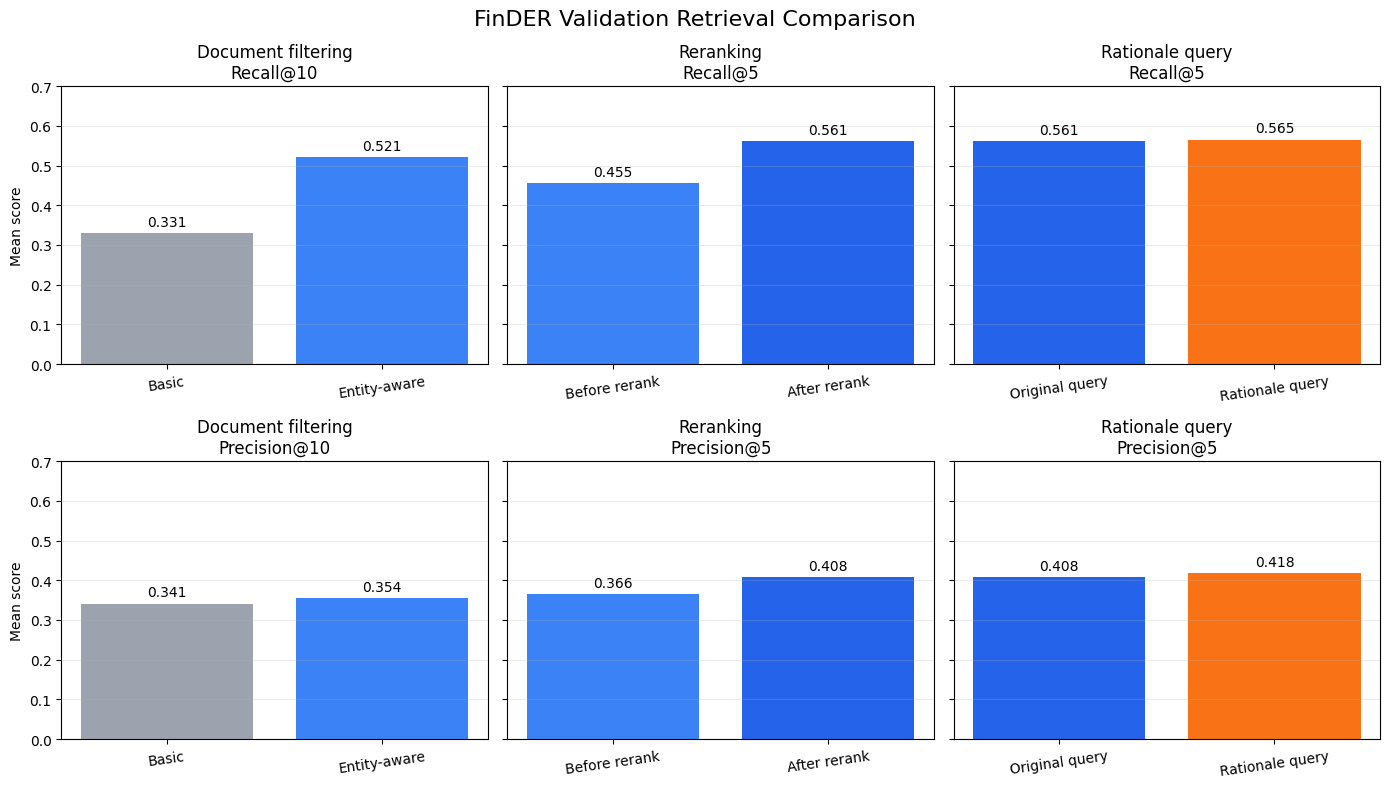

,comparison,metric,method,mean,count
0,Document filtering,Recall@10,basic,0.3307,569
1,Document filtering,Recall@10,entity_aware,0.5209,569
2,Document filtering,Precision@10,basic,0.3413,569
3,Document filtering,Precision@10,entity_aware,0.3543,569
4,Reranking,Recall@5,entity_aware,0.4549,569
5,Reranking,Recall@5,entity_aware_reranked,0.5612,569
6,Reranking,Precision@5,entity_aware,0.3660,569
7,Reranking,Precision@5,entity_aware_reranked,0.4079,569
8,Rationale query,Recall@5,entity_aware_reranked,0.5612,569
9,Rationale query,Recall@5,rationale_entity_aware_reranked,0.5652,569


In [15]:
import matplotlib.pyplot as plt


# 다른 retrieve 방식들의 평가 결과 불러오기
recall_all_df = pd.read_parquet(
    "validation_context_recall_flash_lite.parquet"
)

precision_at10_df = pd.read_parquet(
    "validation_context_precision_at10_flash_lite.parquet"
)

entity_recall_at5_df = pd.read_parquet(
    "validation_context_recall_"
    "entity_aware_at5_flash_lite.parquet"
)

precision_at5_df = pd.read_parquet(
    "validation_context_precision_flash_lite.parquet"
)


# 새 rationale 평가 결과 로드
rationale_recall_at5_df = pd.read_parquet(
    "validation_context_recall_"
    "rationale_at5_flash_lite.parquet"
)

rationale_precision_at5_df = pd.read_parquet(
    "validation_context_precision_"
    "rationale_at5_flash_lite.parquet"
)


summary_parts = []


def add_summary(
    source_df,
    methods,
    score_column,
    comparison,
    metric,
):
    selected_df = source_df[
        source_df["method"].isin(methods)
        & source_df["error"].isna()
    ]

    summary_df = (
        selected_df
        .groupby("method")[
            score_column
        ]
        .agg(
            [
                "mean",
                "count",
            ]
        )
        .reset_index()
    )

    summary_df["comparison"] = comparison
    summary_df["metric"] = metric

    summary_parts.append(
        summary_df[
            [
                "comparison",
                "metric",
                "method",
                "mean",
                "count",
            ]
        ]
    )


# 1. Document filtering: Basic vs Entity-aware
add_summary(
    source_df=recall_all_df,
    methods=[
        "basic",
        "entity_aware",
    ],
    score_column="context_recall",
    comparison="Document filtering",
    metric="Recall@10",
)

add_summary(
    source_df=precision_at10_df,
    methods=[
        "basic",
        "entity_aware",
    ],
    score_column="context_precision",
    comparison="Document filtering",
    metric="Precision@10",
)


# 2. Reranking: Before vs After
reranking_recall_df = pd.concat(
    [
        entity_recall_at5_df,
        recall_all_df[
            recall_all_df["method"]
            == "entity_aware_reranked"
        ],
    ],
    ignore_index=True,
)

add_summary(
    source_df=reranking_recall_df,
    methods=[
        "entity_aware",
        "entity_aware_reranked",
    ],
    score_column="context_recall",
    comparison="Reranking",
    metric="Recall@5",
)

add_summary(
    source_df=precision_at5_df,
    methods=[
        "entity_aware",
        "entity_aware_reranked",
    ],
    score_column="context_precision",
    comparison="Reranking",
    metric="Precision@5",
)


# 3. Rationale: Original query vs Rationale query
rationale_recall_comparison_df = pd.concat(
    [
        recall_all_df[
            recall_all_df["method"]
            == "entity_aware_reranked"
        ],
        rationale_recall_at5_df,
    ],
    ignore_index=True,
)

rationale_precision_comparison_df = pd.concat(
    [
        precision_at5_df[
            precision_at5_df["method"]
            == "entity_aware_reranked"
        ],
        rationale_precision_at5_df,
    ],
    ignore_index=True,
)

add_summary(
    source_df=rationale_recall_comparison_df,
    methods=[
        "entity_aware_reranked",
        "rationale_entity_aware_reranked",
    ],
    score_column="context_recall",
    comparison="Rationale query",
    metric="Recall@5",
)

add_summary(
    source_df=rationale_precision_comparison_df,
    methods=[
        "entity_aware_reranked",
        "rationale_entity_aware_reranked",
    ],
    score_column="context_precision",
    comparison="Rationale query",
    metric="Precision@5",
)


comparison_summary_df = pd.concat(
    summary_parts,
    ignore_index=True,
)


# 평가가 누락된 상태에서 그래프가 생성되는 것을 방지
if not comparison_summary_df[
    "count"
].eq(569).all():
    incomplete_results = comparison_summary_df[
        comparison_summary_df["count"] != 569
    ]

    raise RuntimeError(
        "완료되지 않은 평가 결과가 있습니다:\n"
        f"{incomplete_results}"
    )


stage_order = [
    "Document filtering",
    "Reranking",
    "Rationale query",
]

metric_by_row = [
    [
        "Recall@10",
        "Recall@5",
        "Recall@5",
    ],
    [
        "Precision@10",
        "Precision@5",
        "Precision@5",
    ],
]

label_map = {
    (
        "Document filtering",
        "basic",
    ): "Basic",
    (
        "Document filtering",
        "entity_aware",
    ): "Entity-aware",
    (
        "Reranking",
        "entity_aware",
    ): "Before rerank",
    (
        "Reranking",
        "entity_aware_reranked",
    ): "After rerank",
    (
        "Rationale query",
        "entity_aware_reranked",
    ): "Original query",
    (
        "Rationale query",
        "rationale_entity_aware_reranked",
    ): "Rationale query",
}

color_map = {
    "basic": "#9CA3AF",
    "entity_aware": "#3B82F6",
    "entity_aware_reranked": "#2563EB",
    "rationale_entity_aware_reranked": "#F97316",
}


y_max = min(
    1.0,
    max(
        0.7,
        comparison_summary_df["mean"].max()
        + 0.1,
    ),
)

figure, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharey=True,
)


for column_index, comparison in enumerate(
    stage_order
):
    for row_index in range(2):
        metric = metric_by_row[
            row_index
        ][column_index]

        axis = axes[
            row_index,
            column_index,
        ]

        panel_df = comparison_summary_df[
            (
                comparison_summary_df[
                    "comparison"
                ]
                == comparison
            )
            & (
                comparison_summary_df[
                    "metric"
                ]
                == metric
            )
        ]

        bars = axis.bar(
            range(len(panel_df)),
            panel_df["mean"],
            color=[
                color_map[method]
                for method in panel_df["method"]
            ],
        )

        axis.set_xticks(
            range(len(panel_df)),
            [
                label_map[
                    (
                        comparison,
                        method,
                    )
                ]
                for method in panel_df["method"]
            ],
            rotation=8,
        )

        axis.set_title(
            f"{comparison}\n{metric}"
        )
        axis.set_ylim(
            0,
            y_max,
        )
        axis.grid(
            axis="y",
            alpha=0.25,
        )
        axis.bar_label(
            bars,
            fmt="%.3f",
            padding=3,
        )


axes[0, 0].set_ylabel(
    "Mean score"
)
axes[1, 0].set_ylabel(
    "Mean score"
)

figure.suptitle(
    "FinDER Validation Retrieval Comparison",
    fontsize=16,
)

plt.tight_layout()
plt.show()


comparison_summary_df.assign(
    mean=comparison_summary_df[
        "mean"
    ].round(4)
)